<h2>Load in Dataset</h2>

In [1]:
%matplotlib ipympl

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map
from sunpy.net import Fido, attrs as a
from astropy import units as u
from astropy.coordinates import SkyCoord
import sunpy_soar
from glob import glob
from IPython.display import HTML
from astropy.io import fits
from astropy.time import Time
from datetime import datetime
#from pastamarkers import pasta, salsa
from stixpy.product import Product
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
import scipy

In [3]:
plt.close('all')

In [4]:
short_exposure_images = glob(r'C:\python_code\hrishort\*.fits')

In [5]:
initial_map = sunpy.map.Map(short_exposure_images[200])

In [6]:
tr_x=3170
tr_y=-620
bl_x=3050
bl_y=-800

In [7]:
top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=initial_map.coordinate_frame)
bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=initial_map.coordinate_frame)
short_exposure_map_seq = initial_map.submap(bottom_left=bottom_left, top_right=top_right)
#short_exposure_map_seq.quicklook()

In [8]:
second_map = sunpy.map.Map(short_exposure_images[201])
top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=second_map.coordinate_frame)
bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=second_map.coordinate_frame)
second_map_crop = second_map.submap(bottom_left=bottom_left, top_right=top_right)
short_exposure_map_seq = sunpy.map.Map([short_exposure_map_seq, second_map_crop], sequence = True)
third_map = sunpy.map.Map(short_exposure_images[202])
top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=third_map.coordinate_frame)
bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=third_map.coordinate_frame)
third_map_crop = third_map.submap(bottom_left=bottom_left, top_right=top_right)
short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [third_map_crop], sequence = True)

In [9]:
for i in range(98):
    next_map = sunpy.map.Map(short_exposure_images[203+i])
    top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=next_map.coordinate_frame)
    bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=next_map.coordinate_frame)
    next_map_crop = next_map.submap(bottom_left=bottom_left, top_right=top_right)
    short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [next_map_crop], sequence = True)

In [10]:
euitimes = []
for i in range(101):
    hdul = fits.open(short_exposure_images[200+i])
    hdu1 = hdul[1]
    euitimes.append(hdu1.header["DATE-BEG"])
    hdul.close()

In [11]:
euitimes = Time(euitimes).to_datetime()

In [12]:
unmasked_map_seq = short_exposure_map_seq

In [13]:
lightcurves = np.zeros([293*397, len(unmasked_map_seq)])

In [14]:
lightcurve_max = 0
for i in range(290):
    for j in range(395):
        for k in range(len(unmasked_map_seq)):
            #print(masked_map_seq_3[k].data[j,i])
            lightcurves[i*j, k] = unmasked_map_seq[k].data[j,i]
            if unmasked_map_seq[k].data[j,i] > lightcurve_max:
                lightcurve_max = unmasked_map_seq[k].data[j,i]

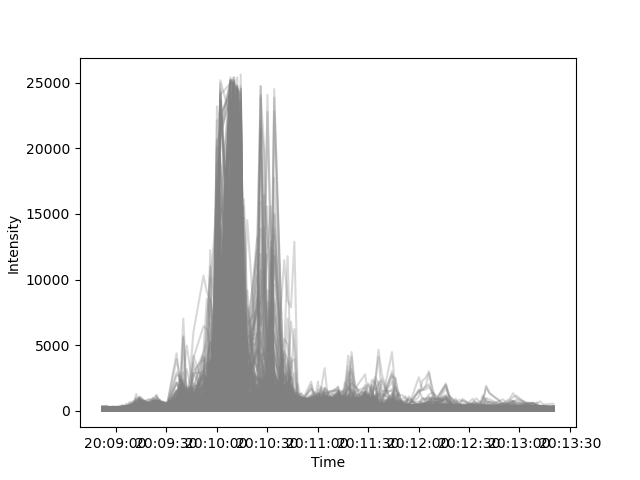

In [15]:
fig4 = plt.figure()#figsize =(10, 5))
ax4 = fig4.add_subplot(111)
for n in range(293*397):
    #print(n)
    flag = False
    for k in range(len(unmasked_map_seq)):
        if lightcurves[n, k] != 0:
            flag = True
    if flag == True:
        ax4.plot(euitimes, (lightcurves[n,]), color = 'gray', alpha = 0.3)
        # try:
            
        # except:
        #     ax4.plot(euitimes[:67], (lightcurves[n,]), color = 'gray', alpha = 0.3)
#ax4.plot(euitimes, average_intensity_10, color = 'red')
ax4.set_xlabel("Time")
ax4.set_ylabel("Intensity")



#ax4.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h2>Determine max value of each lightcurve</h2>

In [16]:
lightcurves

array([[ 55.,  45.,  55., ...,  66.,  55.,  66.],
       [190., 210., 190., ..., 120., 120., 136.],
       [190., 190., 190., ..., 120., 136., 136.],
       ...,
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.]], shape=(116321, 101))

In [17]:
lightcurve_maxs = np.zeros([293*397])
for n in range(293*397):
    maxx = 0
    for k in range(100):
        if lightcurves[n, k] > maxx:
            maxx = lightcurves[n,k]
            lightcurve_maxs[n] = lightcurves[n,k]

<h2>Unordered plot of lightcurves</h2>

In [18]:
non_zero_lightcurves = []
for n in range(len(lightcurve_maxs)):
    if lightcurve_maxs[n] > 0:
        non_zero_lightcurves.append(lightcurves[n,])

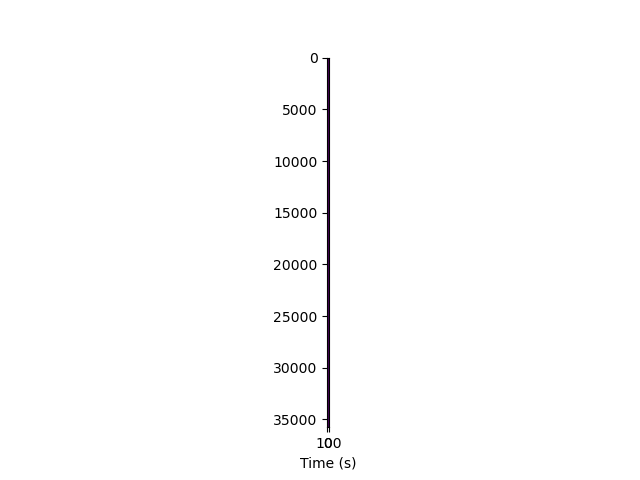

In [19]:
fig, ax = plt.subplots()
im = ax.imshow(non_zero_lightcurves)

ax.set_xlabel("Time (s)")
#ax.set_xlim([0,70])
# fig.tight_layout()
plt.show()

<h2>Bin lightcurves by maximum value</h2>

In [20]:
lightcurve_max_val = lightcurve_maxs.max()
print(lightcurve_max_val)

25651.0


In [21]:
peak_50max = []
peak_30max = []
peak_20max = []
peak_10max = []
peak_below = []

In [22]:
for n in range(len(lightcurve_maxs)):
    if lightcurve_maxs[n] >= 0.5*lightcurve_max_val:
        peak_50max.append(lightcurves[n,])
    if lightcurve_maxs[n] >= 0.3*lightcurve_max_val:
        peak_30max.append(lightcurves[n,])
    if lightcurve_maxs[n] >= 0.2*lightcurve_max_val:
        peak_20max.append(lightcurves[n,])
    if lightcurve_maxs[n] >= 0.1*lightcurve_max_val:
        peak_10max.append(lightcurves[n,])
    if lightcurve_maxs[n] < 0.1*lightcurve_max_val:
        peak_below.append(lightcurves[n,])

<h2>Lightcurves with peak > 0.5max</h2>

In [23]:
intensity_50 = peak_50max

In [24]:
norm_intensity_50 = np.zeros([len(intensity_50), 101])
for i in range(len(intensity_50)):
    maxx = 0
    for n in range(len(intensity_50[i])):
        if intensity_50[i][n] > maxx:
            maxx = intensity_50[i][n]
    norm_intensity_50[i] = intensity_50[i]/maxx

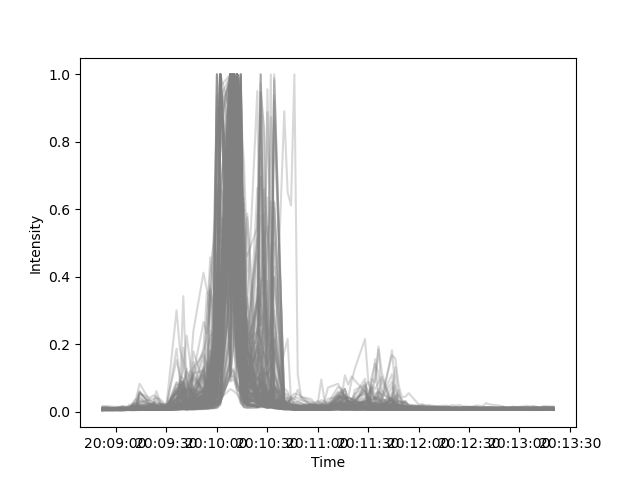

In [25]:
figa = plt.figure()
axa = figa.add_subplot(111)
for n in range(len(intensity_50)):
    axa.plot(euitimes, norm_intensity_50[n,], color = 'gray', alpha = 0.3)
axa.set_xlabel("Time")
axa.set_ylabel("Intensity")
#ax4.set_xlim(euitimes[10], euitimes[20])
plt.show()

In [26]:
len(intensity_50)

142

<h3>Remove lightcurves with more than one peak above 0.3</h3>

In [27]:
single_peak_50 = []
for n in range(len(intensity_50)):
    peaks = scipy.signal.find_peaks(norm_intensity_50[n], height = 0.3)
    if peaks[0].shape[0] == 1:
        single_peak_50.append(norm_intensity_50[n])

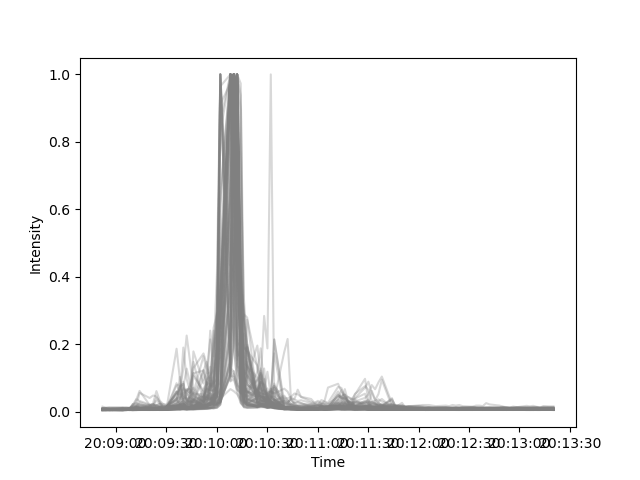

In [28]:
figb = plt.figure()
axb = figb.add_subplot(111)
for n in range(len(single_peak_50)):
    axb.plot(euitimes, single_peak_50[n], color = 'gray', alpha = 0.3)
axb.set_xlabel("Time")
axb.set_ylabel("Intensity")
plt.show()

<h3>Align curves so they peak at the same time</h3>

In [29]:
flare_times = []
for n in range(15):
    flare_times.append(datetime(2024, 4, 5, 19, 59, (2*n)+30, 00000))
for n in range(15):
    flare_times.append(datetime(2024, 4, 5, 20, 00, 2*n, 00000))
flare_times.append(datetime(2024, 4, 5, 20, 00, 30, 00000))

In [30]:
shift_peak_time = datetime(2024, 4, 5, 20, 00, 00, 00000)
euitimes_shifted_50 = []

In [31]:
for n in range(len(single_peak_50)):
    peak = scipy.signal.find_peaks(single_peak_50[n], height = 0.3)[0][0]
    deltat = euitimes[peak] - shift_peak_time
    euitimes_shifted_50.append(euitimes - deltat)

In [32]:
average_intensity_50 = np.zeros(len(flare_times))
for k in range(len(flare_times)):
    count = 0
    for n in range(len(euitimes_shifted_50)):
        for m in range(len(euitimes_shifted_50[n])):
            if euitimes_shifted_50[n][m].hour == flare_times[k].hour and euitimes_shifted_50[n][m].minute == flare_times[k].minute and euitimes_shifted_50[n][m].second == flare_times[k].second:
                #print(flare_times[k])
                #print(euitimes_shifted[n][m])
                average_intensity_50[k] = average_intensity_50[k] + single_peak_50[n][m]
                #print(average_intensity_10[k])
                count = count + 1
    average_intensity_50[k] = average_intensity_50[k]/count

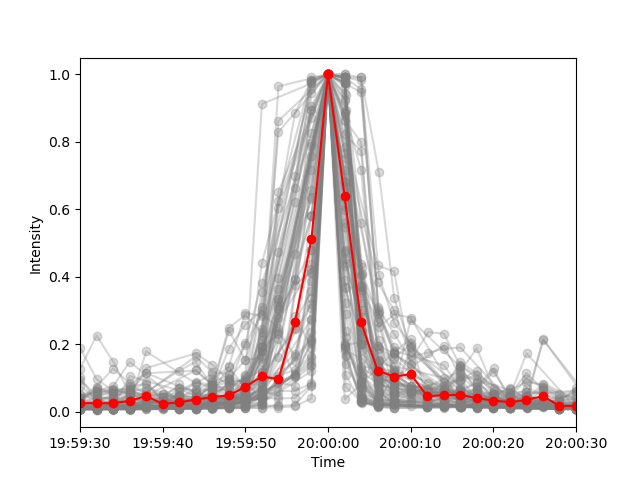

In [33]:
figc = plt.figure()
axc = figc.add_subplot(111)
for n in range(len(single_peak_50)):
    axc.plot(euitimes_shifted_50[n], single_peak_50[n], color = 'gray', alpha = 0.3, marker = 'o')
axc.plot(flare_times, average_intensity_50, 'r-o')
axc.set_xlabel("Time")
axc.set_ylabel("Intensity")
axc.set_xlim([datetime(2024, 4, 5, 19, 59, 30, 00000), datetime(2024, 4, 5, 20, 00, 30, 00000)])
plt.show()

<h3>Rise/Decay from average intensity</h3>

In [34]:
#determine peaks then determine FWHM of peaks
#second array outputted gives the intensity values of the FWHM
peak, _ = scipy.signal.find_peaks(average_intensity_50)
results_half = scipy.signal.peak_widths(average_intensity_50, peak, rel_height=0.5)
results_half

(array([1.23243647, 0.63897392, 2.34849048, 0.55483858, 1.55093873,
        1.06603469]),
 array([0.03532164, 0.10034438, 0.51162713, 0.1074453 , 0.04777749,
        0.0372765 ]),
 array([ 3.23362651, 10.86102608, 13.99420521, 19.5       , 21.6511375 ,
        27.23821607]),
 array([ 4.46606298, 11.5       , 16.34269569, 20.05483858, 23.20207623,
        28.30425075]))

In [35]:
X = np.zeros(len(flare_times))
for n in range(15):
    X[n] = flare_times[n].second
for n in range(16):
    X[n+15] = flare_times[n+15].second + 60

In [36]:
#interpolate average intensity points
xnew = np.linspace(30, 90, 1001)
ynew = np.interp(xnew, X, average_intensity_50)

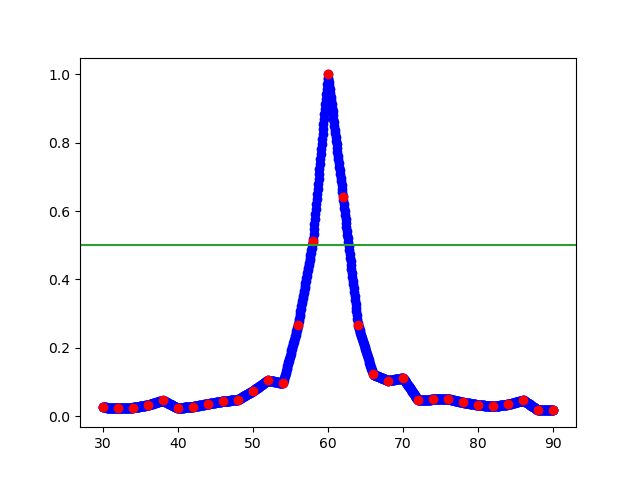

In [37]:
fign = plt.figure()
axn = fign.add_subplot(111)
axn.plot(xnew, ynew, 'bo')
axn.plot(X, average_intensity_50, 'ro')
axn.axhline(0.5, color="C2")
plt.show()

In [38]:
ynew[500]

np.float64(1.0)

In [39]:
ynew[465]

np.float64(0.5006638838638207)

In [40]:
xnew[465]

np.float64(57.9)

In [41]:
ynew[546]

np.float64(0.4976400004048469)

In [42]:
ynew[545]

np.float64(0.5088884027010775)

In [43]:
xnew[546]

np.float64(62.76)

<h2>Lightcurves with peak >0.3max</h2>

In [44]:
intensity_30 = peak_50max + peak_30max

In [45]:
norm_intensity_30 = np.zeros([len(intensity_30), 101])
for i in range(len(intensity_30)):
    maxx = 0
    for n in range(len(intensity_30[i])):
        if intensity_30[i][n] > maxx:
            maxx = intensity_30[i][n]
    norm_intensity_30[i] = intensity_30[i]/maxx

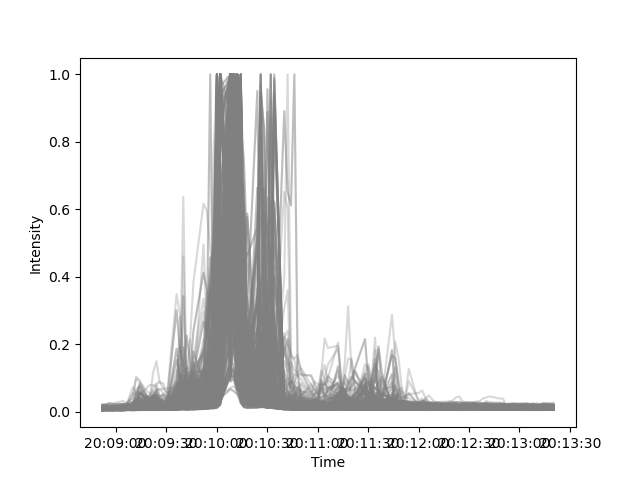

In [46]:
figa = plt.figure()
axa = figa.add_subplot(111)
for n in range(len(intensity_30)):
    axa.plot(euitimes, norm_intensity_30[n,], color = 'gray', alpha = 0.3)
axa.set_xlabel("Time")
axa.set_ylabel("Intensity")
#ax4.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Remove lightcurves with more than one peak above 0.3</h3>

In [47]:
single_peak_30 = []
for n in range(len(intensity_30)):
    peaks = scipy.signal.find_peaks(norm_intensity_30[n], height = 0.3)
    if peaks[0].shape[0] == 1:
        single_peak_30.append(norm_intensity_30[n])

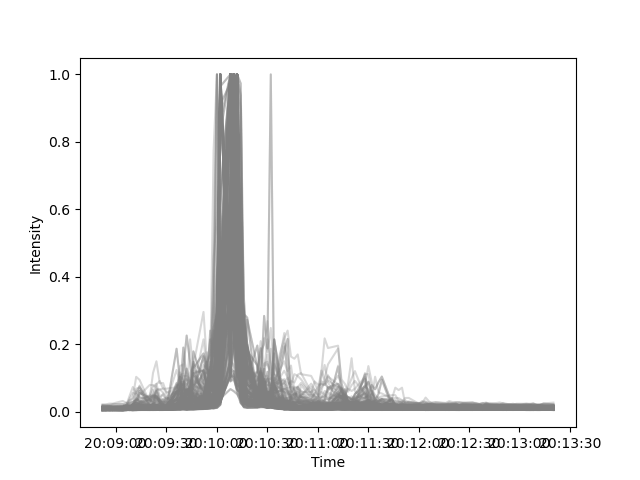

In [48]:
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
for n in range(len(single_peak_30)):
    ax2.plot(euitimes, single_peak_30[n], color = 'gray', alpha = 0.3)
ax2.set_xlabel("Time")
ax2.set_ylabel("Intensity")
#ax2.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Align curves so they peak at the same time</h3>

In [49]:
shift_peak_time = datetime(2024, 4, 5, 20, 00, 00, 00000)
euitimes_shifted_30 = []

In [50]:
for n in range(len(single_peak_30)):
    peak = scipy.signal.find_peaks(single_peak_30[n], height = 0.3)[0][0]
    deltat = euitimes[peak] - shift_peak_time
    euitimes_shifted_30.append(euitimes - deltat)

In [51]:
average_intensity_30 = np.zeros(len(flare_times))
for k in range(len(flare_times)):
    count = 0
    for n in range(len(euitimes_shifted_30)):
        for m in range(len(euitimes_shifted_30[n])):
            if euitimes_shifted_30[n][m].hour == flare_times[k].hour and euitimes_shifted_30[n][m].minute == flare_times[k].minute and euitimes_shifted_30[n][m].second == flare_times[k].second:
                #print(flare_times[k])
                #print(euitimes_shifted[n][m])
                average_intensity_30[k] = average_intensity_30[k] + single_peak_30[n][m]
                #print(average_intensity_10[k])
                count = count + 1
    average_intensity_30[k] = average_intensity_30[k]/count

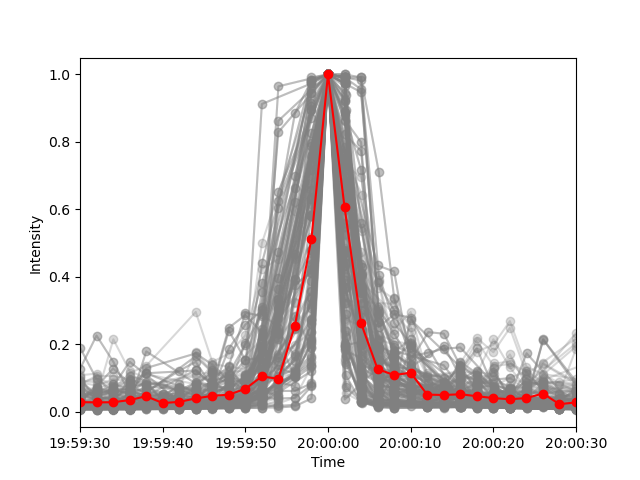

In [52]:
fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
for n in range(len(single_peak_30)):
    ax3.plot(euitimes_shifted_30[n], single_peak_30[n], color = 'gray', alpha = 0.3, marker = 'o')
ax3.plot(flare_times, average_intensity_30, 'r-o')
ax3.set_xlabel("Time")
ax3.set_ylabel("Intensity")
ax3.set_xlim([datetime(2024, 4, 5, 19, 59, 30, 00000), datetime(2024, 4, 5, 20, 00, 30, 00000)])
plt.show()

<h3>Rise/decay from average intensity</h3>

In [53]:
#determine peaks then determine FWHM of peaks
#second array outputted gives the intensity values of the FWHM
peak, _ = scipy.signal.find_peaks(average_intensity_30)
results_half = scipy.signal.peak_widths(average_intensity_30, peak, rel_height=0.5)
results_half

(array([1.24936526, 0.59805285, 2.27502265, 0.55421705, 0.69241718,
        0.90067677]),
 array([0.03656685, 0.10082325, 0.51270852, 0.11192834, 0.05038961,
        0.04518832]),
 array([ 3.20241857, 10.90194715, 13.99747834, 19.5       , 22.5       ,
        27.36895635]),
 array([ 4.45178383, 11.5       , 16.27250099, 20.05421705, 23.19241718,
        28.26963312]))

In [54]:
#interpolate average intensity points
xnew = np.linspace(30, 90, 1001)
ynew = np.interp(xnew, X, average_intensity_30)

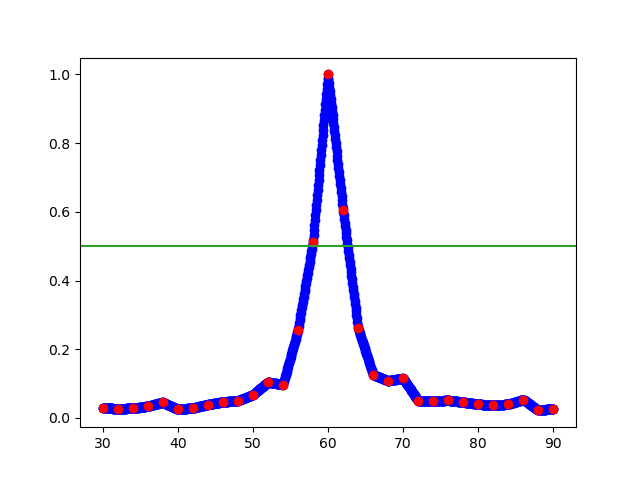

In [55]:
figm = plt.figure()
axm = figm.add_subplot(111)
axm.plot(xnew, ynew, 'bo')
axm.plot(X, average_intensity_30, 'ro')
axm.axhline(0.5, color="C2")
plt.show()

In [56]:
ynew[500]

np.float64(1.0)

In [57]:
ynew[465]

np.float64(0.5004603281155421)

In [58]:
xnew[465]

np.float64(57.9)

In [59]:
ynew[543]

np.float64(0.5066811296637842)

In [60]:
ynew[544]

np.float64(0.49634787302880157)

In [61]:
xnew[544]

np.float64(62.64)

<h2>Lightcurves with peak >0.2max</h2>

In [62]:
intensity_20 = peak_50max + peak_30max + peak_20max

In [63]:
norm_intensity_20 = np.zeros([len(intensity_20), 101])
for i in range(len(intensity_20)):
    maxx = 0
    for n in range(len(intensity_20[i])):
        if intensity_20[i][n] > maxx:
            maxx = intensity_20[i][n]
    norm_intensity_20[i] = intensity_20[i]/maxx

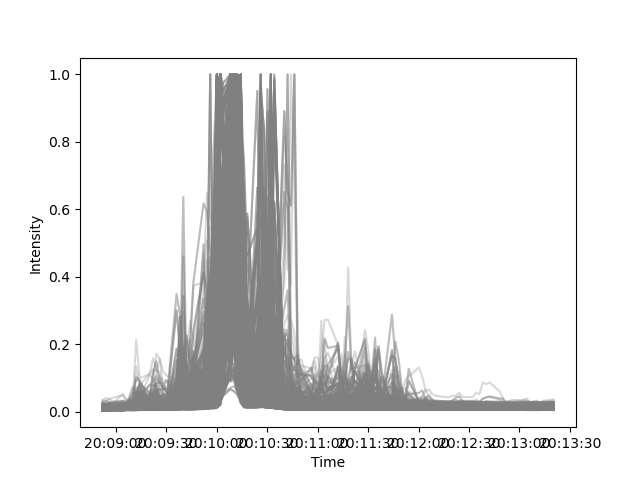

In [64]:
fig7 = plt.figure()
ax7 = fig7.add_subplot(111)
for n in range(len(intensity_20)):
    ax7.plot(euitimes, norm_intensity_20[n,], color = 'gray', alpha = 0.3)
#ax4.plot(euitimes, average_intensity_10, color = 'red')
ax7.set_xlabel("Time")
ax7.set_ylabel("Intensity")
#ax4.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Remove lightcurves with more than one peak > 0.3</h3>

In [65]:
single_peak_20 = []
for n in range(len(intensity_20)):
    peaks = scipy.signal.find_peaks(norm_intensity_20[n], height = 0.3)
    if peaks[0].shape[0] == 1:
        single_peak_20.append(norm_intensity_20[n])

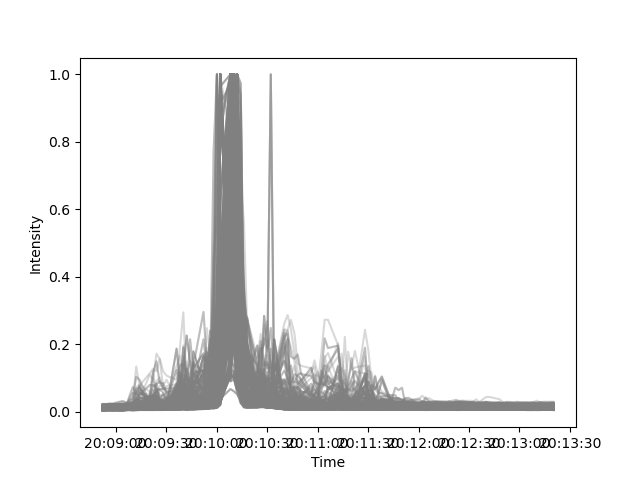

In [66]:
fig8 = plt.figure()
ax8 = fig8.add_subplot(111)
for n in range(len(single_peak_20)):
    ax8.plot(euitimes, single_peak_20[n], color = 'gray', alpha = 0.3)
ax8.set_xlabel("Time")
ax8.set_ylabel("Intensity")
#ax8.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Align curves so they all peak at the same time</h3>

In [67]:
shift_peak_time = datetime(2024, 4, 5, 20, 00, 00, 00000)
euitimes_shifted_20 = []

In [68]:
for n in range(len(single_peak_20)):
    peak = scipy.signal.find_peaks(single_peak_20[n], height = 0.3)[0][0]
    deltat = euitimes[peak] - shift_peak_time
    euitimes_shifted_20.append(euitimes - deltat)

In [69]:
average_intensity_20 = np.zeros(len(flare_times))
for k in range(len(flare_times)):
    count = 0
    for n in range(len(euitimes_shifted_20)):
        for m in range(len(euitimes_shifted_20[n])):
            if euitimes_shifted_20[n][m].hour == flare_times[k].hour and euitimes_shifted_20[n][m].minute == flare_times[k].minute and euitimes_shifted_20[n][m].second == flare_times[k].second:
                #print(flare_times[k])
                #print(euitimes_shifted[n][m])
                average_intensity_20[k] = average_intensity_20[k] + single_peak_20[n][m]
                #print(average_intensity_10[k])
                count = count + 1
    average_intensity_20[k] = average_intensity_20[k]/count

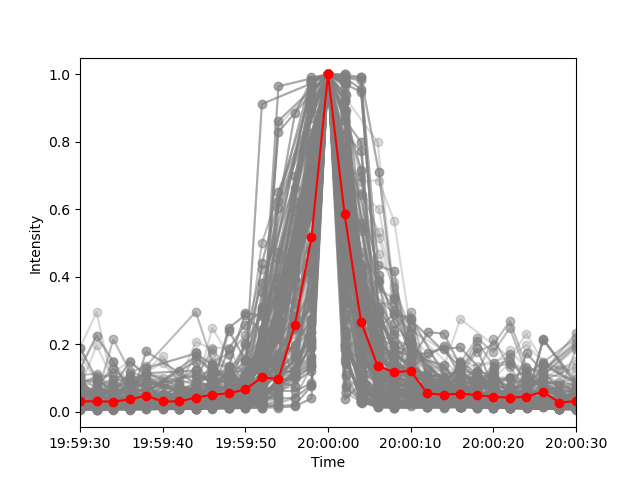

In [70]:
fig9 = plt.figure()
ax9 = fig9.add_subplot(111)
for n in range(len(single_peak_20)):
    ax9.plot(euitimes_shifted_20[n], single_peak_20[n], color = 'gray', alpha = 0.3, marker = 'o')
ax9.plot(flare_times, average_intensity_20, 'r-o')
ax9.set_xlabel("Time")
ax9.set_ylabel("Intensity")
ax9.set_xlim([datetime(2024, 4, 5, 19, 59, 30, 00000), datetime(2024, 4, 5, 20, 00, 30, 00000)])
plt.show()

<h3>Rise/decay times from average</h3>

In [71]:
#determine peaks then determine FWHM of peaks
#second array outputted gives the intensity values of the FWHM
peak, _ = scipy.signal.find_peaks(average_intensity_20)
results_half = scipy.signal.peak_widths(average_intensity_20, peak, rel_height=0.5)
results_half

(array([1.25944446, 0.56717541, 2.22964821, 0.53127443, 0.84753647,
        0.87952112]),
 array([0.03873119, 0.09918783, 0.51495169, 0.11902826, 0.05198346,
        0.05013787]),
 array([ 3.24055554, 10.93282459, 13.99334763, 19.5       , 22.5       ,
        27.39349482]),
 array([ 4.5       , 11.5       , 16.22299584, 20.03127443, 23.34753647,
        28.27301594]))

In [72]:
#interpolate average intensity points
xnew = np.linspace(30, 90, 1001)
ynew = np.interp(xnew, X, average_intensity_20)

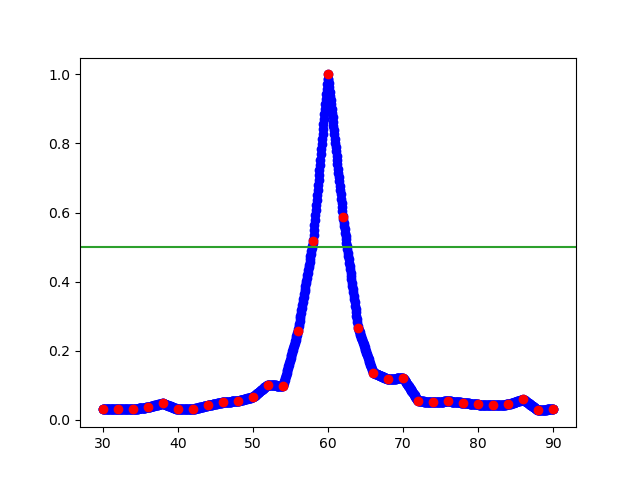

In [73]:
figj = plt.figure()
axj = figj.add_subplot(111)
axj.plot(xnew, ynew, 'bo')
axj.plot(X, average_intensity_20, 'ro')
axj.axhline(0.5, color="C2")
plt.show()

In [74]:
ynew[500]

np.float64(1.0)

In [75]:
ynew[465]

np.float64(0.5037131910490928)

In [76]:
ynew[464]

np.float64(0.4959352569013815)

In [77]:
xnew[465]

np.float64(57.9)

In [78]:
ynew[542]

np.float64(0.5030794638682202)

In [79]:
ynew[543]

np.float64(0.49345441668008655)

In [80]:
xnew[542]

np.float64(62.519999999999996)

<h2>Lightcurves with peak >0.1max</h2>

In [81]:
intensity_10 = peak_50max + peak_30max + peak_20max + peak_10max

In [82]:
norm_intensity_10 = np.zeros([len(intensity_10), 101])
for i in range(len(intensity_10)):
    maxx = 0
    for n in range(len(intensity_10[i])):
        if intensity_10[i][n] > maxx:
            maxx = intensity_10[i][n]
    norm_intensity_10[i] = intensity_10[i]/maxx

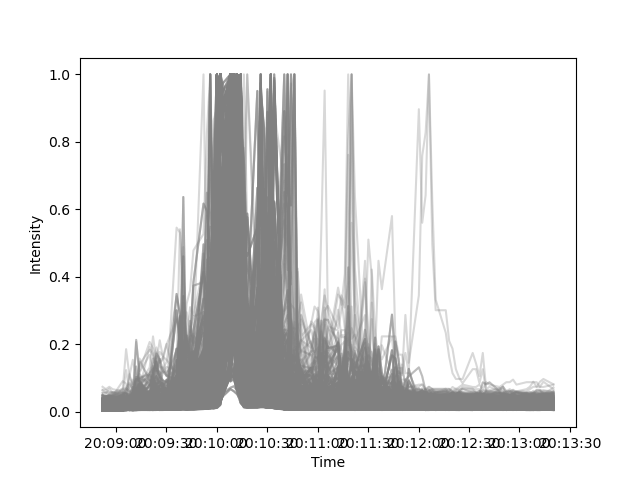

In [83]:
fig4 = plt.figure()
ax4 = fig4.add_subplot(111)
for n in range(len(intensity_10)):
    ax4.plot(euitimes, norm_intensity_10[n,], color = 'gray', alpha = 0.3)
#ax4.plot(euitimes, average_intensity_10, color = 'red')
ax4.set_xlabel("Time")
ax4.set_ylabel("Intensity")
#ax4.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Remove curves with more than one peak above 0.3</h3>

In [84]:
single_peak_10 = []
for n in range(len(intensity_10)):
    peaks = scipy.signal.find_peaks(norm_intensity_10[n], height = 0.3)
    if peaks[0].shape[0] == 1:
        single_peak_10.append(norm_intensity_10[n])

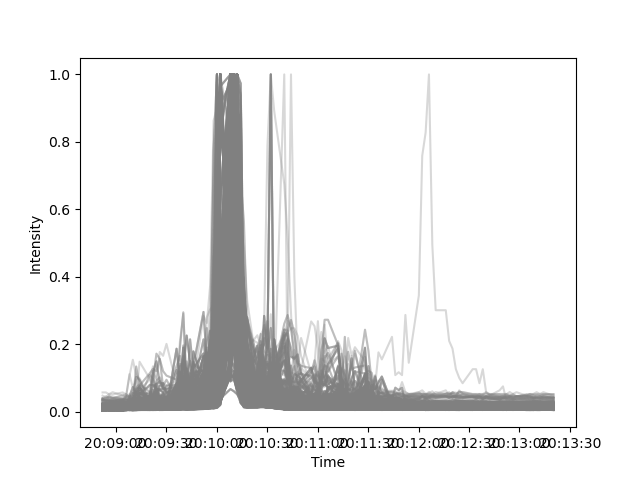

In [85]:
fig5 = plt.figure()
ax5 = fig5.add_subplot(111)
for n in range(len(single_peak_10)):
    ax5.plot(euitimes, single_peak_10[n], color = 'gray', alpha = 0.3)
ax5.set_xlabel("Time")
ax5.set_ylabel("Intensity")
#ax5.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Align curves so they peak at the same time</h3>

In [86]:
shift_peak_time = datetime(2024, 4, 5, 20, 00, 00, 00000)
euitimes_shifted_10 = []

In [87]:
for n in range(len(single_peak_10)):
    peak = scipy.signal.find_peaks(single_peak_10[n], height = 0.3)[0][0]
    deltat = euitimes[peak] - shift_peak_time
    euitimes_shifted_10.append(euitimes - deltat)

In [88]:
average_intensity_10 = np.zeros(len(flare_times))
for k in range(len(flare_times)):
    count = 0
    for n in range(len(euitimes_shifted_10)):
        for m in range(len(euitimes_shifted_10[n])):
            if euitimes_shifted_10[n][m].hour == flare_times[k].hour and euitimes_shifted_10[n][m].minute == flare_times[k].minute and euitimes_shifted_10[n][m].second == flare_times[k].second:
                #print(flare_times[k])
                #print(euitimes_shifted[n][m])
                average_intensity_10[k] = average_intensity_10[k] + single_peak_10[n][m]
                #print(average_intensity_10[k])
                count = count + 1
    average_intensity_10[k] = average_intensity_10[k]/count

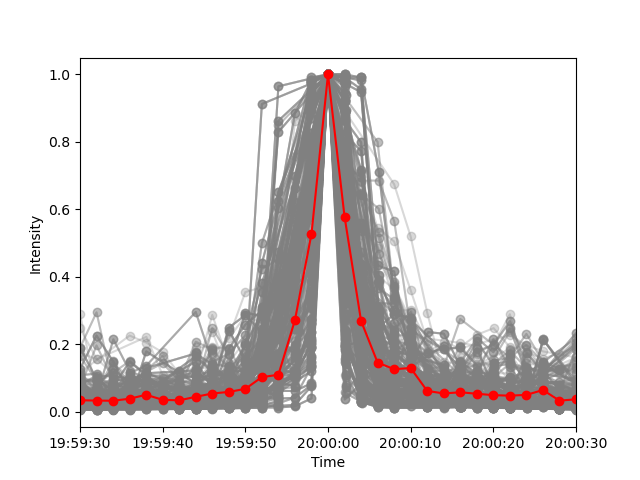

In [89]:
figz = plt.figure()
axz = figz.add_subplot(111)
for n in range(len(single_peak_10)):
    axz.plot(euitimes_shifted_10[n], single_peak_10[n], color = 'gray', alpha = 0.3, marker = 'o')
axz.plot(flare_times, average_intensity_10, 'r-o')
axz.set_xlabel("Time")
axz.set_ylabel("Intensity")
axz.set_xlim([datetime(2024, 4, 5, 19, 59, 30, 00000), datetime(2024, 4, 5, 20, 00, 30, 00000)])
plt.show()

<h3>Rise/decay from average intensity</h3>

In [90]:
#determine peaks then determine FWHM of peaks
#second array outputted gives the intensity values of the FWHM
peak, _ = scipy.signal.find_peaks(average_intensity_10)
results_half = scipy.signal.peak_widths(average_intensity_10, peak, rel_height=0.5)
results_half

(array([1.26132117, 2.24215319, 0.52459378, 0.9042945 , 0.84935832]),
 array([0.04171268, 0.5163203 , 0.12754527, 0.05564668, 0.05566402]),
 array([ 3.29190912, 13.95878596, 19.5       , 22.5       , 27.41625396]),
 array([ 4.55323029, 16.20093915, 20.02459378, 23.4042945 , 28.26561228]))

In [91]:
#interpolate average intensity points
xnew = np.linspace(30, 90, 1001)
ynew = np.interp(xnew, X, average_intensity_10)

In [ ]:
figk = plt.figure()
axk = figk.add_subplot(111)
axk.plot(xnew, ynew, 'bo')
axk.plot(X, average_intensity_10, 'ro')
axk.axhline(0.5, color="C2")
plt.show()

In [93]:
ynew[500]

np.float64(1.0)

In [94]:
ynew[464]

np.float64(0.5064143566969891)

In [95]:
ynew[463]

np.float64(0.4987523511015254)

In [96]:
xnew[463]

np.float64(57.78)

In [97]:
ynew[541]

np.float64(0.507322885149367)

In [98]:
ynew[542]

np.float64(0.4980347055391046)

In [99]:
xnew[542]

np.float64(62.519999999999996)

<h2>Rise and Decay Times</h2>

| Threshold | FWHM rise time | Max Intensity | FWHM decay time | $t_{rise}$ | $t_{decay}$ |
| :- | :-: | :-: | :-: | :-: | :-: |
| $10\%$ | 57.78 | 60 | 62.52 | 2.22 | 2.52 |
| $20\%$ | 57.90 | 60 | 62.52 | 2.10 | 2.52 |
| $30\%$ | 57.90 | 60 | 62.64 | 2.10 | 2.64 |
| $50\%$ | 57.90 | 60 | 62.76 | 2.10 | 2.76 |